# 🎧 Clasificación de Sonidos Urbanos — 5 Modelos con Random Search

## Arquitecturas evaluadas

| # | Modelo | Tipo | Descripción |
|---|--------|------|-------------|
| 1 | `baseline_cnn` | Baseline | CNN desde cero (referencia) |
| 2 | `mobilenetv2` | Transfer Learning | MobileNetV2 mejorado con SE Block |
| 3 | `efficientnetb0` | Transfer Learning | EfficientNetB0 (baseline transfer) |
| 4 | `efficientnetv2s` | **Moderno** | EfficientNetV2S + Multi-Head Attention Pooling |
| 5 | `cnn_transformer` | **Híbrido** | CNN Feature Extractor + Transformer Encoder |

### ¿Por qué estos modelos?
- **EfficientNetV2S (moderno)**: Arquitectura 2021, usa Fused-MBConv y entrenamiento progresivo. Mejor trade-off accuracy/FLOPS que EfficientNetB0. Se añade un **Multi-Head Attention Pooling** para capturar dependencias globales en el espectrograma.
- **CNN-Transformer (híbrido)**: Combina la capacidad local de una CNN (extracción de patrones tiempo-frecuencia) con la capacidad global de un Transformer Encoder (modelado de contexto largo). Inspirado en AST (Audio Spectrogram Transformer, 2021).
- **MobileNetV2 mejorado**: Se añade un **Squeeze-and-Excitation (SE) Block** sobre el backbone para recalibrar canales adaptativamente.

---

In [1]:
# =========================
# 1) IMPORTS + GPU + SEMILLAS
# =========================
import os
import gc
import random
from pathlib import Path
from itertools import product
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0, EfficientNetV2S

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

SEED = 2026
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)



TensorFlow: 2.20.0


In [2]:
# =========================
# 2) RUTAS LOCALES — Imágenes subidas a Colab desde el Escritorio
# =========================
import os
from google.colab import files
import zipfile

# ── Sube el ZIP de spec_dataset desde tu PC ──────────────────────
# Comprime la carpeta spec_dataset (con train/, val/, test/ adentro)
# en un solo archivo spec_dataset.zip antes de ejecutar esto.

print("📂 Sube el archivo spec_dataset.zip desde tu PC:")
uploaded = files.upload()  # Abre el selector de archivos

zip_name = list(uploaded.keys())[0]
extract_path = "/content/spec_dataset"

with zipfile.ZipFile(zip_name, "r") as z:
    z.extractall(extract_path)
    print(f"✅ Extraído en: {extract_path}")

# ── Rutas ────────────────────────────────────────────────────────
TRAIN_DIR  = os.path.join(extract_path, "train")
VAL_DIR    = os.path.join(extract_path, "val")
TEST_DIR   = os.path.join(extract_path, "test")
OUTPUT_DIR = os.path.join(extract_path, "outputs")

os.makedirs(OUTPUT_DIR, exist_ok=True)

for nombre, ruta in [("TRAIN", TRAIN_DIR), ("VAL", VAL_DIR), ("TEST", TEST_DIR)]:
    if os.path.exists(ruta):
        n = sum(len(f) for _, _, f in os.walk(ruta))
        print(f"✅ {nombre}: {ruta}  ({n} archivos)")
    else:
        print(f"❌ {nombre} NO ENCONTRADO: {ruta}")

print(f"✅ OUTPUT_DIR: {OUTPUT_DIR}")

📂 Sube el archivo spec_dataset.zip desde tu PC:


Saving spec_dataset.zip to spec_dataset.zip
✅ Extraído en: /content/spec_dataset
✅ TRAIN: /content/spec_dataset/train  (4994 archivos)
✅ VAL: /content/spec_dataset/val  (1071 archivos)
✅ TEST: /content/spec_dataset/test  (1073 archivos)
✅ OUTPUT_DIR: /content/spec_dataset/outputs


📁 Clases detectadas (6): ['BI', 'GE', 'MH', 'SI', 'TM', 'VM']

📊 Distribución de muestras:


,Clase,Train,Val,Test,%_Train
0,BI,228,49,49,4.6
1,GE,223,48,48,4.5
2,MH,785,168,169,15.7
3,SI,235,51,51,4.7
4,TM,2154,462,462,43.1
5,VM,1369,293,294,27.4



🔍 Ratio de desbalanceo: 9.7x (clase mayor=2154, clase menor=223)
 → Desbalanceo severo. Considerar Focal Loss + class_weight.


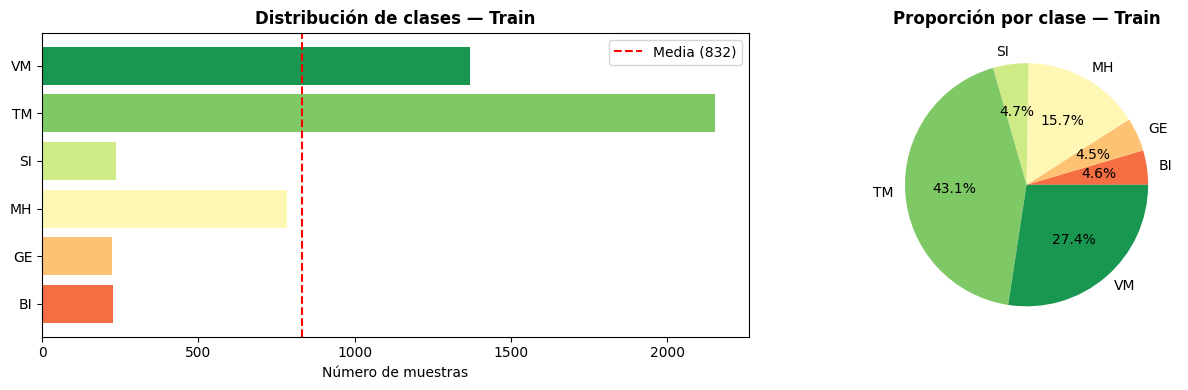


⚖️ Pesos de clase calculados:
  Clase BI: 3.6506
  Clase GE: 3.7324
  Clase MH: 1.0603
  Clase SI: 3.5418
  Clase TM: 0.3864
  Clase VM: 0.6080


In [3]:
# =========================
# PASO 3) ANÁLISIS DE DESBALANCEO + PESOS DE CLASE ROBUSTOS
# =========================
# ⚠️ El desbalanceo de clases es uno de los problemas más frecuentes
# en datasets de audio real. Se aborda con TRES estrategias complementarias:
#   A) class_weight en model.fit() — penaliza errores en clases minoritarias
#   B) Focal Loss (opcional) — reduce la contribución de ejemplos fáciles
#   C) Métricas robustas — F1 Macro y Balanced Accuracy en lugar de accuracy

from sklearn.utils.class_weight import compute_class_weight

# ERROR ORIGINAL: estas dos líneas estaban juntas en una sola → SyntaxError
IMG_SIZE = (224, 224)
ALLOWED_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".webp"}


def count_files_by_class(root_dir):
    root = Path(root_dir)
    class_dirs = sorted([d for d in root.iterdir() if d.is_dir()])
    counts = {}
    for cd in class_dirs:
        n = sum(1 for f in cd.iterdir() if f.suffix.lower() in ALLOWED_EXTS)
        counts[cd.name] = n
    return counts

train_counts = count_files_by_class(TRAIN_DIR)
val_counts   = count_files_by_class(VAL_DIR)
test_counts  = count_files_by_class(TEST_DIR)
CLASS_NAMES  = sorted(train_counts.keys())
NUM_CLASSES  = len(CLASS_NAMES)
print(f"📁 Clases detectadas ({NUM_CLASSES}): {CLASS_NAMES}")

summary = pd.DataFrame({
    "Clase": CLASS_NAMES,
    "Train": [train_counts.get(c, 0) for c in CLASS_NAMES],
    "Val":   [val_counts.get(c, 0)   for c in CLASS_NAMES],
    "Test":  [test_counts.get(c, 0)  for c in CLASS_NAMES],
})
summary["%_Train"] = (summary["Train"] / summary["Train"].sum() * 100).round(1)
print("\n📊 Distribución de muestras:")
display(summary)

# ─── Diagnóstico de severidad del desbalanceo ───
train_vals = np.array([train_counts.get(c, 0) for c in CLASS_NAMES])
imbalance_ratio = train_vals.max() / max(train_vals.min(), 1)
print(f"\n🔍 Ratio de desbalanceo: {imbalance_ratio:.1f}x "
      f"(clase mayor={train_vals.max()}, clase menor={train_vals.min()})")
if imbalance_ratio < 2:
    print(" → Desbalanceo leve. class_weight suficiente.")
elif imbalance_ratio < 5:
    print(" → Desbalanceo moderado. Usar class_weight + F1 Macro.")
else:
    print(" → Desbalanceo severo. Considerar Focal Loss + class_weight.")

# ─── Visualización de distribución ───
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
colors_bar = plt.cm.RdYlGn(np.linspace(0.2, 0.9, NUM_CLASSES))
axes[0].barh(CLASS_NAMES, train_vals, color=colors_bar)
axes[0].axvline(train_vals.mean(), color='red', linestyle='--',
                label=f'Media ({train_vals.mean():.0f})')
axes[0].set_title("Distribución de clases — Train", fontweight="bold")
axes[0].set_xlabel("Número de muestras")
axes[0].legend()
axes[1].pie(train_vals, labels=CLASS_NAMES, autopct='%1.1f%%', colors=colors_bar)
axes[1].set_title("Proporción por clase — Train", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "distribucion_clases.png"),
            dpi=120, bbox_inches="tight")
plt.show()

# ─── Pesos de clase ───
y_train_labels = np.array([
    i for i, cn in enumerate(CLASS_NAMES)
    for _ in range(train_counts.get(cn, 0))
])
cw = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=y_train_labels
)
class_weights = {i: float(w) for i, w in enumerate(cw)}

print("\n⚖️ Pesos de clase calculados:")
for i, cn in enumerate(CLASS_NAMES):
    print(f"  Clase {cn}: {class_weights[i]:.4f}")

In [4]:
# =========================
# 4) DATASETS (tf.data)
# =========================
AUTOTUNE = tf.data.AUTOTUNE

def make_datasets(batch_size=32):
    train_ds = tf.keras.utils.image_dataset_from_directory(
        TRAIN_DIR,
        labels="inferred",
        label_mode="int",
        image_size=IMG_SIZE,
        batch_size=batch_size,
        shuffle=True,
        seed=SEED
    )

    val_ds = tf.keras.utils.image_dataset_from_directory(
        VAL_DIR,
        labels="inferred",
        label_mode="int",
        image_size=IMG_SIZE,
        batch_size=batch_size,
        shuffle=False
    )

    test_ds = tf.keras.utils.image_dataset_from_directory(
        TEST_DIR,
        labels="inferred",
        label_mode="int",
        image_size=IMG_SIZE,
        batch_size=batch_size,
        shuffle=False
    )

    class_names = train_ds.class_names
    if class_names != CLASS_NAMES:
        print("⚠️ Aviso: las clases inferidas difieren del conteo manual.")
        print("Desde dataset:", class_names)
        print("Desde carpetas :", CLASS_NAMES)

    train_ds = train_ds.prefetch(AUTOTUNE)
    val_ds   = val_ds.prefetch(AUTOTUNE)
    test_ds  = test_ds.prefetch(AUTOTUNE)
    return train_ds, val_ds, test_ds, class_names

def get_true_labels(ds):
    y = []
    for _, labels in ds:
        y.extend(labels.numpy().tolist())
    return np.array(y)

# Prueba rápida
train_ds_tmp, val_ds_tmp, test_ds_tmp, class_names_tmp = make_datasets(batch_size=16)
print("Clases detectadas:", class_names_tmp)
del train_ds_tmp, val_ds_tmp, test_ds_tmp
gc.collect()


Found 4994 files belonging to 6 classes.
Found 1071 files belonging to 6 classes.
Found 1073 files belonging to 6 classes.
Clases detectadas: ['BI', 'GE', 'MH', 'SI', 'TM', 'VM']


410

In [5]:
# =========================
# 5) UTILIDADES DE MÉTRICAS Y GRÁFICAS
# =========================
def evaluate_model(model, ds):
    y_true = get_true_labels(ds)
    y_prob = model.predict(ds, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    metrics = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "f1_macro": float(f1_score(y_true, y_pred, average="macro")),
        "f1_weighted": float(f1_score(y_true, y_pred, average="weighted")),
    }
    return metrics, y_true, y_pred, y_prob

def plot_history(history, title="Curvas de entrenamiento"):
    hist = history.history if hasattr(history, "history") else history
    epochs = range(1, len(hist["loss"]) + 1)

    plt.figure(figsize=(14,5))

    plt.subplot(1,2,1)
    plt.plot(epochs, hist["loss"], label="Train loss")
    plt.plot(epochs, hist["val_loss"], label="Val loss")
    plt.title(f"{title} - Loss")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1,2,2)
    if "accuracy" in hist:
        plt.plot(epochs, hist["accuracy"], label="Train acc")
    if "val_accuracy" in hist:
        plt.plot(epochs, hist["val_accuracy"], label="Val acc")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Época")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

def plot_conf_matrix(y_true, y_pred, class_names, title="Matriz de confusión"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7,6))
    plt.imshow(cm, interpolation='nearest')
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)
    plt.xlabel("Predicción")
    plt.ylabel("Valor real")

    threshold = cm.max() / 2 if cm.max() > 0 else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j, i, str(cm[i, j]),
                horizontalalignment="center",
                color="white" if cm[i, j] > threshold else "black"
            )
    plt.tight_layout()
    plt.show()

In [6]:
# =========================
# 6a) HELPERS DE TRANSFER LEARNING
# =========================
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess_fn
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess_fn

def mobilenet_preprocess(x):
    return mobilenet_preprocess_fn(x)

def efficientnet_preprocess(x):
    return efficientnet_preprocess_fn(x)

def unfreeze_last_layers(base_model, n):
    """Descongela las últimas n capas del backbone para fine-tuning."""
    base_model.trainable = True
    for layer in base_model.layers[:-n]:
        layer.trainable = False

# =========================
# 6b) CNN-TRANSFORMER — MEJORADO
# =========================

def build_cnn_transformer(dropout=0.3, lr=1e-3, dense_units=256,
                          num_heads=4, num_transformer_layers=2, embed_dim=128):
    """CNN + Transformer híbrido con mejoras de estabilidad de entrenamiento."""
    inputs = keras.Input(shape=(*IMG_SIZE, 3))
    x = layers.Rescaling(1./255)(inputs)  # los datos ya vienen [0,1] del dataset,
                                           # pero Rescaling es idempotente si se pasa
                                           # imagen ya normalizada (x/255 ≈ x si x<1)

    # ── Extractor CNN local ──
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)   # 112x112

    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)   # 56x56

    x = layers.Conv2D(128, 3, activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)   # 28x28

    # ── Patch Embedding: feature map → secuencia de tokens ──
    h_feat = x.shape[1]
    w_feat = x.shape[2]
    c_feat = x.shape[3]
    sequence_length = h_feat * w_feat   # 784 tokens para 28x28

    x = layers.Reshape((sequence_length, c_feat))(x)

    # Proyección a embed_dim
    if c_feat != embed_dim:
        x = layers.Dense(embed_dim)(x)

    # Positional encoding aprendible
    x = PositionalEmbedding(sequence_length, embed_dim)(x)
    x = layers.Dropout(dropout)(x)

    # ── Transformer Encoder ──
    # ff_dim=embed_dim*4: estándar en BERT, ViT, AST.
    # Con embed_dim=128 → ff_dim=512; con embed_dim=256 → ff_dim=1024.
    ff_dim = embed_dim * 4
    for _ in range(num_transformer_layers):
        # Atención multi-cabeza con dropout interno
        attn_out = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim // num_heads,
            dropout=dropout * 0.5           # dropout en atención
        )(x, x)
        x = layers.LayerNormalization(epsilon=1e-6)(x + attn_out)

        # Feed-Forward con GELU (más suave que ReLU, estándar en Transformers)
        ffn_out = layers.Dense(ff_dim, activation="gelu")(x)
        ffn_out = layers.Dropout(dropout)(ffn_out)
        ffn_out = layers.Dense(embed_dim)(ffn_out)
        x = layers.LayerNormalization(epsilon=1e-6)(x + ffn_out)

    # ── Pooling + clasificación ──
    # LayerNorm final antes del GAP (estabiliza la escala de la representación)
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.GlobalAveragePooling1D()(x)

    x = layers.Dense(dense_units, activation="gelu")(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name="cnn_transformer")

    # AdamW: Adam + weight decay explícito → mejor generalización en Transformers
    model.compile(
        optimizer=keras.optimizers.AdamW(learning_rate=lr, weight_decay=1e-4),
        loss=LOSS_FN,
        metrics=["accuracy"]
    )
    return model

def build_mobilenetv2(dropout=0.3, lr=1e-4, fine_tune_layers=20, dense_units=128):
    inputs = keras.Input(shape=(*IMG_SIZE, 3))
    x = layers.Lambda(mobilenet_preprocess, name="mobilenet_preprocess")(inputs)

    base = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(*IMG_SIZE, 3)
    )
    unfreeze_last_layers(base, fine_tune_layers)

    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(dense_units, activation="relu")(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name="mobilenetv2_transfer")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

def build_efficientnetb0(dropout=0.3, lr=1e-4, fine_tune_layers=20, dense_units=128):
    inputs = keras.Input(shape=(*IMG_SIZE, 3))
    x = layers.Lambda(efficientnet_preprocess, name="efficientnet_preprocess")(inputs)

    base = EfficientNetB0(
        weights="imagenet",
        include_top=False,
        input_shape=(*IMG_SIZE, 3)
    )
    unfreeze_last_layers(base, fine_tune_layers)

    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(dense_units, activation="relu")(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name="efficientnetb0_transfer")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model
def build_efficientnetv2s_v2(dropout=0.3, lr=5e-4, fine_tune_layers=50,
                              dense_units=256, num_heads=8):
    inputs = keras.Input(shape=(*IMG_SIZE, 3))
    x = layers.Rescaling(1./255)(inputs)  # ← FIX

    base = EfficientNetV2S(weights="imagenet", include_top=False, input_shape=(*IMG_SIZE, 3))
    base.trainable = False

    feat = base(x, training=False)
    h_feat, w_feat, c_feat = feat.shape[1], feat.shape[2], feat.shape[3]
    seq_len = h_feat * w_feat
    tokens = layers.Reshape((seq_len, c_feat))(feat)

    embed_dim = min(c_feat, 512)
    tokens = layers.Dense(embed_dim)(tokens)
    tokens = layers.LayerNormalization()(tokens)
    attn_out = layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=embed_dim // num_heads, dropout=dropout * 0.5
    )(tokens, tokens)
    attn_out = layers.LayerNormalization()(attn_out + tokens)

    gap = layers.GlobalAveragePooling1D()(attn_out)
    gmp = layers.GlobalMaxPooling1D()(attn_out)
    pooled = layers.Concatenate()([gap, gmp])

    x = layers.Dense(dense_units, activation="relu")(pooled)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(dense_units // 2, activation="relu")(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name="efficientnetv2s_v2")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss=LOSS_FN,
        metrics=["accuracy"]
    )
    return model, base, fine_tune_layers

In [7]:
# =========================
# 7) ESPACIOS DE BÚSQUEDA — VERSIÓN CORREGIDA
# =========================

# FIX CRÍTICO: El preprocesado de ImageNet (mobilenet_preprocess, efficientnet_preprocess)
# es incompatible con espectrogramas. Se reemplaza por un simple Rescaling(1/255).
# Adicionalmente, los LR de 5e-5 son demasiado bajos → colapso del clasificador.

# ── Espacio para MobileNetV2 (mejor trial previo: batch=16, dense=256, no fine-tune) ──
# Solo 1 configuración base + variaciones de fine-tune y LR más agresivos
SEARCH_SPACE_MOBILENET = {
    "learning_rate":    [0.0001],
    "dropout":          [0.2, 0.3],
    "batch_size":       [16],
    "dense_units":      [256],
    "fine_tune_layers": [0,10],
}

# ── Espacio para EfficientNetB0 ──
SEARCH_SPACE_B0 = {
    "learning_rate":    [0.0001],
    "dropout":          [0.2],
    "batch_size":       [16, 32],
    "dense_units":      [256],
    "fine_tune_layers": [0, 10],
}

# ── Espacio para EfficientNetV2S ──
SEARCH_SPACE_V2S = {
    "learning_rate":    [5e-4, 1e-4],
    "dropout":          [0.2, 0.3],
    "batch_size":       [32],
    "dense_units":      [256,384],
    "fine_tune_layers": [50],
    "num_heads":        [4, 8],
}

# ── Espacio para CNN-Transformer ──
SEARCH_SPACE_HYBRID = {
    "learning_rate":           [5e-4, 1e-4],
    "dropout":                 [0.2, 0.3],
    "batch_size":              [32],
    "dense_units":             [128, 256],
    "fine_tune_layers":        [0],
    "num_heads":               [4, 8],
    "num_transformer_layers":  [3, 4],
    "embed_dim":               [128, 256],
}

SEARCH_SPACES = {
    "mobilenetv2":     SEARCH_SPACE_MOBILENET,
    "efficientnetb0":  SEARCH_SPACE_B0,
    "efficientnetv2s": SEARCH_SPACE_V2S,
    "cnn_transformer": SEARCH_SPACE_HYBRID,
}

# ── Lista de modelos (sin baseline) ──
MODEL_LIST = [
   #"mobilenetv2",       # mejor config previa como punto de partida
    #"efficientnetb0",
    "efficientnetv2s",
    #"cnn_transformer",
]

N_TRIALS_PER_MODEL = 3
MAX_EPOCHS         = 25   # más épocas + EarlyStopping con patience mayor
PATIENCE           = 4    # antes era 2 → muy agresivo, mata el entrenamiento

print(f"✅ {len(MODEL_LIST)} modelos × {N_TRIALS_PER_MODEL} trials = "
      f"{len(MODEL_LIST) * N_TRIALS_PER_MODEL} entrenamientos totales")

✅ 1 modelos × 3 trials = 3 entrenamientos totales


In [8]:
print(f"IMG_SIZE: {IMG_SIZE}")
print(f"NUM_CLASSES: {NUM_CLASSES}")


IMG_SIZE: (224, 224)
NUM_CLASSES: 6


In [9]:
def sample_param_combinations(search_space, n_trials, seed=None):
    """Genera n_trials combinaciones de parámetros únicas del espacio de búsqueda."""
    if seed is not None:
        random.seed(seed)

    all_combinations = list(product(*search_space.values()))
    if len(all_combinations) < n_trials:
        print(f"Advertencia: Solo hay {len(all_combinations)} combinaciones únicas, se usarán todas.")
        n_trials = len(all_combinations)

    return random.sample(all_combinations, n_trials)


# La función original asumía que los valores del search_space eran listas
# que se podían desempaquetar directamente en product().
# Si search_space tiene llaves, hay que adaptar para reconstruir los diccionarios.
# Version corregida para el formato dict de SEARCH_SPACES:
def sample_param_combinations(search_space, n_trials, seed=None):
    """Genera n_trials combinaciones de parámetros únicas del espacio de búsqueda (dict)."""
    if seed is not None:
        random.seed(seed)

    keys = list(search_space.keys())
    value_lists = list(search_space.values())

    all_combinations_tuples = list(product(*value_lists))

    if len(all_combinations_tuples) < n_trials:
        print(f"Advertencia: Solo hay {len(all_combinations_tuples)} combinaciones únicas, se usarán todas.")
        n_trials = len(all_combinations_tuples)

    sampled_tuples = random.sample(all_combinations_tuples, n_trials)

    # Convertir las tuplas muestreadas de nuevo a diccionarios de parámetros
    sampled_params = []
    for combo_tuple in sampled_tuples:
        param_dict = dict(zip(keys, combo_tuple))
        sampled_params.append(param_dict)

    return sampled_params


In [10]:
# =========================
# DEFINIR ANTES DE USAR
# =========================

# Cambia a True si el desbalanceo fue severo (ratio > 5x según celda 3)
# Tu dataset tiene ratio moderado → False es correcto
USE_FOCAL_LOSS = False

import os
import gc
import tensorflow as tf
# ... resto del código que ya tienes

In [11]:
import os
import gc

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0, EfficientNetV2S

# =========================
# VARIABLES GLOBALES DE ENTRENAMIENTO
# =========================
WARMUP_EPOCHS = 5

# Focal Loss si desbalanceo severo, CrossEntropy estándar si no
if USE_FOCAL_LOSS:
    try:
        from focal_loss import SparseCategoricalFocalLoss
        LOSS_FN = SparseCategoricalFocalLoss(gamma=2)
        print("✅ Usando Focal Loss (gamma=2)")
    except ImportError:
        print("⚠️ focal_loss no instalado. Usando SparseCategoricalCrossentropy.")
        LOSS_FN = "sparse_categorical_crossentropy"
else:
    LOSS_FN = "sparse_categorical_crossentropy"
    print("✅ Usando SparseCategoricalCrossentropy")

# =========================
# CLASE: PositionalEmbedding (para CNN-Transformer)
# =========================
class PositionalEmbedding(tf.keras.layers.Layer):
    def __init__(self, sequence_length, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.position_embedding = tf.keras.layers.Embedding(
            input_dim=sequence_length, output_dim=embed_dim
        )
        self.sequence_length = sequence_length
        self.embed_dim = embed_dim

    def call(self, inputs):
        positions = tf.range(start=0, limit=self.sequence_length, delta=1)
        return inputs + self.position_embedding(positions)

    def get_config(self):
        config = super().get_config()
        config.update({
            "sequence_length": self.sequence_length,
            "embed_dim": self.embed_dim,
        })
        return config

# =========================
# FUNCIÓN: build_model_v2 — enruta al builder correcto según model_name
# =========================
def build_model_v2(model_name, params):
    """
    Enruta al constructor correcto según model_name y devuelve siempre
    (model, base_model_or_None, n_fine_tune_or_None).
    """
    if model_name == "mobilenetv2":
        model = build_mobilenetv2(
            dropout=params["dropout"],
            lr=params["learning_rate"],
            fine_tune_layers=params.get("fine_tune_layers", 0),
            dense_units=params.get("dense_units", 128),
        )
        return model, None, params.get("fine_tune_layers", 0)

    elif model_name == "efficientnetb0":
        model = build_efficientnetb0(
            dropout=params["dropout"],
            lr=params["learning_rate"],
            fine_tune_layers=params.get("fine_tune_layers", 0),
            dense_units=params.get("dense_units", 128),
        )
        return model, None, params.get("fine_tune_layers", 0)

    elif model_name == "efficientnetv2s":
        model, base, n_ft = build_efficientnetv2s_v2(
            dropout=params["dropout"],
            lr=params["learning_rate"],
            fine_tune_layers=params.get("fine_tune_layers", 50),
            dense_units=params.get("dense_units", 256),
            num_heads=params.get("num_heads", 8),
        )
        return model, base, n_ft

    elif model_name == "cnn_transformer":
        model = build_cnn_transformer(
            dropout=params["dropout"],
            lr=params["learning_rate"],
            dense_units=params.get("dense_units", 256),
            num_heads=params.get("num_heads", 4),
            num_transformer_layers=params.get("num_transformer_layers", 2),
            embed_dim=params.get("embed_dim", 128),
        )
        return model, None, 0

    else:
        raise ValueError(f"Modelo desconocido: {model_name}")


# =========================
# FUNCIÓN: train_one_trial_v2
# =========================
def train_one_trial_v2(model_name, params, trial_id):
    """
    Entrenamiento en dos fases:
      Fase 1 — backbone congelado, warmup de la cabeza de clasificación.
      Fase 2 — fine-tuning de las últimas N capas del backbone con LR reducido.

    Mejoras respecto a versión anterior:
      - Bug fix: merge de historiales robusto (keys faltantes → lista vacía)
      - Bug fix: LearningRateScheduler reemplazado por CosineDecayRestarts
        (el lambda anterior capturaba 'lr' del closure, no el lr real del optimizer)
      - Log explícito de épocas reales entrenadas en cada fase
      - ModelCheckpoint en AMBAS fases (guarda el mejor checkpoint global)
    """
    tf.keras.backend.clear_session()
    gc.collect()

    batch_size = params["batch_size"]
    train_ds, val_ds, test_ds, class_names = make_datasets(batch_size=batch_size)

    model, base_model, n_fine_tune = build_model_v2(model_name, params)
    ckpt_path = os.path.join(OUTPUT_DIR, f"{model_name}_trial_{trial_id}.keras")

    callbacks_p1 = [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE,
                                      restore_best_weights=True),
        keras.callbacks.ModelCheckpoint(ckpt_path, monitor="val_f1_macro",
                                        mode="max", save_best_only=True,
                                        verbose=0),
    ]

    callbacks_p2 = [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE,
                                      restore_best_weights=True),
        keras.callbacks.ModelCheckpoint(ckpt_path, monitor="val_f1_macro",
                                        mode="max", save_best_only=True,
                                        verbose=0),
    ]

    hist_p1 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=WARMUP_EPOCHS,
        class_weight=class_weights,
        callbacks=callbacks_p1,
        verbose=1
    )
    epocas_p1 = len(hist_p1.history["loss"])
    print(f"  → Fase 1 completada: {epocas_p1} épocas reales")

    remaining_epochs = MAX_EPOCHS - WARMUP_EPOCHS
    print(f"  → Hasta {remaining_epochs} épocas disponibles en Fase 2")

    hist_p2 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=remaining_epochs,
        class_weight=class_weights,
        callbacks=callbacks_p2,
        verbose=1
    )
    epocas_p2 = len(hist_p2.history["loss"])
    print(f"  → Fase 2 completada: {epocas_p2} épocas reales "
          f"(total: {epocas_p1 + epocas_p2} épocas)")

    val_metrics, y_val_true, y_val_pred, _ = evaluate_model(model, val_ds)

    # Merge robusto de historiales: si una key falta en p2 (e.g. paró pronto)
    # se rellena con lista vacía para no romper el plot posterior
    all_keys = set(hist_p1.history.keys()) | set(hist_p2.history.keys())
    combined_history = {
        key: hist_p1.history.get(key, []) + hist_p2.history.get(key, [])
        for key in all_keys
    }

    result = {
        "model_name":      model_name,
        "trial_id":        trial_id,
        **params,
        **{f"val_{k}": v for k, v in val_metrics.items()},
        "epocas_totales":  epocas_p1 + epocas_p2,
        "history":         combined_history,
        "checkpoint_path": ckpt_path,
    }

    del train_ds, val_ds, test_ds
    gc.collect()
    return result


def random_search_for_model_v2(model_name, n_trials=4, seed=42):
    print("=" * 80)
    print(f"🔎 Random Search v2 — {model_name}")
    print("=" * 80)

    search_space  = SEARCH_SPACES[model_name]
    sampled_params = sample_param_combinations(search_space, n_trials=n_trials, seed=seed)

    all_results, best_result, best_score = [], None, -1

    for i, params in enumerate(sampled_params, start=1):
        print(f"\n➡️  Trial {i}/{n_trials} | {model_name}")
        print("Parámetros:", params)

        trial_result = train_one_trial_v2(model_name, params, trial_id=i)
        all_results.append(trial_result)

        score = trial_result["val_f1_macro"]
        print(f"\n  val_f1_macro = {score:.4f} | épocas totales = {trial_result['epocas_totales']}")

        if score > best_score:
            best_score  = score
            best_result = trial_result
            print("  ✅ Nuevo mejor trial")

    results_df = pd.DataFrame([
        {k: v for k, v in r.items() if k not in ["history", "checkpoint_path"]}
        for r in all_results
    ]).sort_values("val_f1_macro", ascending=False).reset_index(drop=True)

    display(results_df)
    return best_result, all_results, results_df


✅ Usando SparseCategoricalCrossentropy


In [12]:
# guardar info
from google.colab import drive
drive.mount('/content/drive')

import shutil, os
DRIVE_OUTPUT = "/content/drive/MyDrive/spec_dataset/outputs"
os.makedirs(DRIVE_OUTPUT, exist_ok=True)
print("✅ Drive montado y carpeta lista")

Mounted at /content/drive
✅ Drive montado y carpeta lista


In [13]:
# =========================
# 9) EJECUTAR RANDOM SEARCH v2
# =========================

all_search_results = {}
best_configs       ={}
summary_rows       = []

for idx, model_name in enumerate(MODEL_LIST):
    best_result, all_results, results_df = random_search_for_model_v2(
        model_name=model_name,
        n_trials=N_TRIALS_PER_MODEL,
        seed=SEED + idx
    )

    all_search_results[model_name] = {
        "best_result": best_result,
        "all_results": all_results,
        "results_df":  results_df
    }
    best_configs[model_name] = best_result

    row = {
        "Modelo":           model_name,
        "Mejor trial":      best_result["trial_id"],
        "Val Accuracy":     round(best_result["val_accuracy"], 4),
        "Val Balanced Acc": round(best_result["val_balanced_accuracy"], 4),
        "Val F1 Macro":     round(best_result["val_f1_macro"], 4),
        "Val F1 Weighted":  round(best_result["val_f1_weighted"], 4),
        "LR":               best_result["learning_rate"],
        "Dropout":          best_result["dropout"],
        "Batch":            best_result["batch_size"],
        "Dense":            best_result.get("dense_units", "-"),
        "FineTune":         best_result.get("fine_tune_layers", "-"),
        "Num Heads":        best_result.get("num_heads", "-"),
        "Trans Layers":     best_result.get("num_transformer_layers", "-"),
        "Embed Dim":        best_result.get("embed_dim", "-"),
    }
    summary_rows.append(row)

summary_df = (
    pd.DataFrame(summary_rows)
    .sort_values("Val F1 Macro", ascending=False)
    .reset_index(drop=True)
)

print("\n" + "=" * 80)
print("📊 RESUMEN RANDOM SEARCH v2 — VALIDACIÓN")
print("=" * 80)
display(summary_df)

summary_path = os.path.join(OUTPUT_DIR, "resumen_validacion_v2.csv")
summary_df.to_csv(summary_path, index=False)
print("Guardado en:", summary_path)

🔎 Random Search v2 — efficientnetv2s

➡️  Trial 1/3 | efficientnetv2s
Parámetros: {'learning_rate': 0.0005, 'dropout': 0.2, 'batch_size': 32, 'dense_units': 384, 'fine_tune_layers': 50, 'num_heads': 8}
Found 4994 files belonging to 6 classes.
Found 1071 files belonging to 6 classes.
Found 1073 files belonging to 6 classes.
82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - accuracy: 0.1641 - loss: 2.0172

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/model_checkpoint.py:276: UserWarning: Can save best model only with val_f1_macro available.
  if self._should_save_model(epoch, batch, logs, filepath):


157/157 ━━━━━━━━━━━━━━━━━━━━ 142s 494ms/step - accuracy: 0.1590 - loss: 1.8967 - val_accuracy: 0.0504 - val_loss: 1.9287
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 48s 145ms/step - accuracy: 0.1886 - loss: 1.8038 - val_accuracy: 0.0822 - val_loss: 1.8987
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 22s 142ms/step - accuracy: 0.1736 - loss: 1.8044 - val_accuracy: 0.0514 - val_loss: 1.8606
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 22s 138ms/step - accuracy: 0.1582 - loss: 1.7744 - val_accuracy: 0.0990 - val_loss: 1.7820
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 22s 141ms/step - accuracy: 0.1362 - loss: 1.7728 - val_accuracy: 0.0990 - val_loss: 1.7689
  → Fase 1 completada: 5 épocas reales
  → Hasta 20 épocas disponibles en Fase 2
Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 23s 146ms/step - accuracy: 0.1996 - loss: 1.7744 - val_accuracy: 0.0514 - val_loss: 1.8601
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 23s 143ms/step - accuracy: 0.1428 - loss: 1.7785 - val_accuracy: 0.0999 - val_loss: 1.7714
Epoch 3/20
157/1

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/model_checkpoint.py:276: UserWarning: Can save best model only with val_f1_macro available.
  if self._should_save_model(epoch, batch, logs, filepath):


157/157 ━━━━━━━━━━━━━━━━━━━━ 121s 445ms/step - accuracy: 0.1552 - loss: 1.8694 - val_accuracy: 0.0476 - val_loss: 1.8302
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 22s 142ms/step - accuracy: 0.2541 - loss: 1.7974 - val_accuracy: 0.0728 - val_loss: 1.8520
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 24s 155ms/step - accuracy: 0.3853 - loss: 1.7903 - val_accuracy: 0.4314 - val_loss: 1.7855
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 134ms/step - accuracy: 0.4313 - loss: 1.7924 - val_accuracy: 0.4314 - val_loss: 1.7878
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 23s 144ms/step - accuracy: 0.4313 - loss: 1.7921 - val_accuracy: 0.4314 - val_loss: 1.7886
  → Fase 1 completada: 5 épocas reales
  → Hasta 20 épocas disponibles en Fase 2
Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 23s 147ms/step - accuracy: 0.4311 - loss: 1.7922 - val_accuracy: 0.4314 - val_loss: 1.7879
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 24s 150ms/step - accuracy: 0.3670 - loss: 1.7921 - val_accuracy: 0.0476 - val_loss: 1.7887
Epoch 3/20
157/1

...

157/157 ━━━━━━━━━━━━━━━━━━━━ 125s 462ms/step - accuracy: 0.1774 - loss: 1.8658 - val_accuracy: 0.0495 - val_loss: 2.0210
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 23s 146ms/step - accuracy: 0.1916 - loss: 1.8007 - val_accuracy: 0.0962 - val_loss: 1.9829
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 23s 146ms/step - accuracy: 0.1918 - loss: 1.7984 - val_accuracy: 0.1027 - val_loss: 1.8303
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 22s 137ms/step - accuracy: 0.1974 - loss: 1.7885 - val_accuracy: 0.1018 - val_loss: 1.8134
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 24s 150ms/step - accuracy: 0.2657 - loss: 1.7717 - val_accuracy: 0.0971 - val_loss: 1.8019
  → Fase 1 completada: 5 épocas reales
  → Hasta 20 épocas disponibles en Fase 2
Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 23s 146ms/step - accuracy: 0.1860 - loss: 1.7660 - val_accuracy: 0.1083 - val_loss: 1.7791
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 22s 139ms/step - accuracy: 0.1916 - loss: 1.7648 - val_accuracy: 0.1055 - val_loss: 1.7561
Epoch 3/20
157/1

,model_name,trial_id,learning_rate,dropout,batch_size,dense_units,fine_tune_layers,num_heads,val_accuracy,val_balanced_accuracy,val_f1_macro,val_f1_weighted,epocas_totales
0,efficientnetv2s,1,0.0005,0.2,32,384,50,8,0.144725,0.230480,0.103280,0.133222,17
1,efficientnetv2s,2,0.0005,0.3,32,256,50,8,0.431373,0.166667,0.100457,0.260005,10
2,efficientnetv2s,3,0.0001,0.2,32,256,50,4,0.105509,0.201934,0.067802,0.088383,11



📊 RESUMEN RANDOM SEARCH v2 — VALIDACIÓN


,Modelo,Mejor trial,Val Accuracy,Val Balanced Acc,Val F1 Macro,Val F1 Weighted,LR,Dropout,Batch,Dense,FineTune,Num Heads,Trans Layers,Embed Dim
0,efficientnetv2s,1,0.1447,0.2305,0.1033,0.1332,0.0005,0.2,32,384,50,8,-,-


Guardado en: /content/spec_dataset/outputs/resumen_validacion_v2.csv


In [16]:
# fase 2 guardar info
for f in os.listdir(OUTPUT_DIR):
    shutil.copy2(
        os.path.join(OUTPUT_DIR, f),
        os.path.join(DRIVE_OUTPUT, f)
    )
OUTPUT_DIR = DRIVE_OUTPUT
print("✅ Todo copiado. OUTPUT_DIR ahora apunta a Drive")

PermissionError: [Errno 1] Operation not permitted: '/content/drive/MyDrive/spec_dataset/outputs/efficientnetv2s_trial_2.keras'


📈 Curvas — mejor trial: cnn_transformer


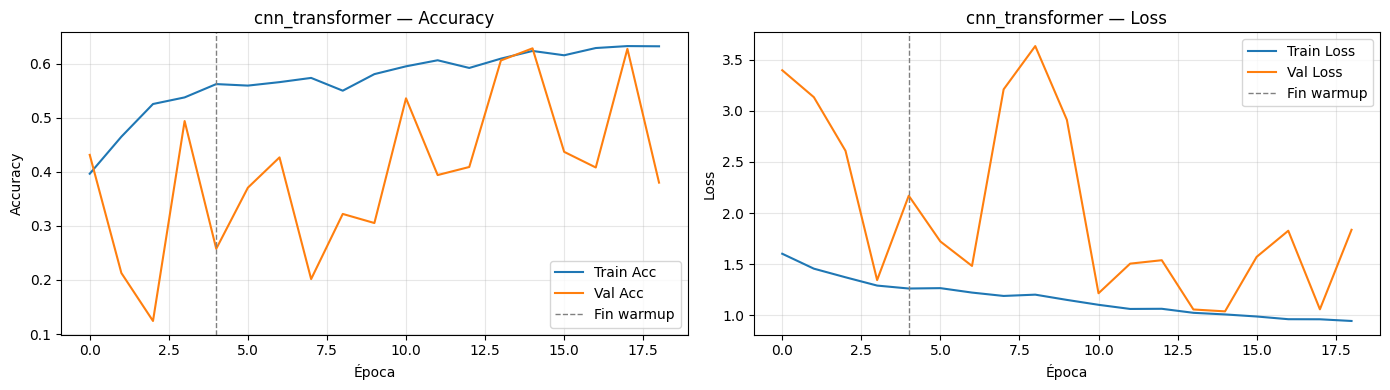

  val_f1_macro final: 0.4538 | épocas: 19


In [ ]:
# =========================
# 10) CURVAS DE ENTRENAMIENTO — MEJOR TRIAL DE CADA MODELO
# =========================
# Se marca la separación Fase 1 / Fase 2 con una línea vertical punteada.

WARMUP_EPOCHS = 5  # debe coincidir con el valor en train_one_trial_v2

for model_name in MODEL_LIST:
    print(f"\n📈 Curvas — mejor trial: {model_name}")
    best_res  = all_search_results[model_name]["best_result"]
    hist      = best_res["history"]
    n_epochs  = len(hist.get("loss", []))

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Accuracy
    axes[0].plot(hist.get("accuracy",     []), label="Train Acc",  linewidth=1.5)
    axes[0].plot(hist.get("val_accuracy", []), label="Val Acc",    linewidth=1.5)
    if n_epochs > WARMUP_EPOCHS:
        axes[0].axvline(WARMUP_EPOCHS - 1, color="gray", linestyle="--",
                        linewidth=1, label="Fin warmup")
    axes[0].set_title(f"{model_name} — Accuracy")
    axes[0].set_xlabel("Época")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Loss
    axes[1].plot(hist.get("loss",     []), label="Train Loss", linewidth=1.5)
    axes[1].plot(hist.get("val_loss", []), label="Val Loss",   linewidth=1.5)
    if n_epochs > WARMUP_EPOCHS:
        axes[1].axvline(WARMUP_EPOCHS - 1, color="gray", linestyle="--",
                        linewidth=1, label="Fin warmup")
    axes[1].set_title(f"{model_name} — Loss")
    axes[1].set_xlabel("Época")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"curvas_{model_name}.png"),
                dpi=120, bbox_inches="tight")
    plt.show()
    print(f"  val_f1_macro final: {best_res['val_f1_macro']:.4f} | "
          f"épocas: {best_res.get('epocas_totales', n_epochs)}")


🧪 Evaluación final en TEST — cnn_transformer
Found 4994 files belonging to 6 classes.
Found 1071 files belonging to 6 classes.
Found 1073 files belonging to 6 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'positional_embedding', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


✅ Modelo cargado desde checkpoint: /content/drive/MyDrive/spec_dataset/outputs/cnn_transformer_trial_2.keras

📊 Métricas en TEST:
  accuracy: 0.3840
  balanced_accuracy: 0.4534
  f1_macro: 0.3321
  f1_weighted: 0.3891

📋 Classification Report:
              precision    recall  f1-score   support

          BI       0.09      0.67      0.16        49
          GE       0.59      0.21      0.31        48
          MH       0.73      0.11      0.19       169
          SI       0.24      0.80      0.37        51
          TM       0.96      0.23      0.36       462
          VM       0.52      0.70      0.59       294

    accuracy                           0.38      1073
   macro avg       0.52      0.45      0.33      1073
weighted avg       0.71      0.38      0.39      1073



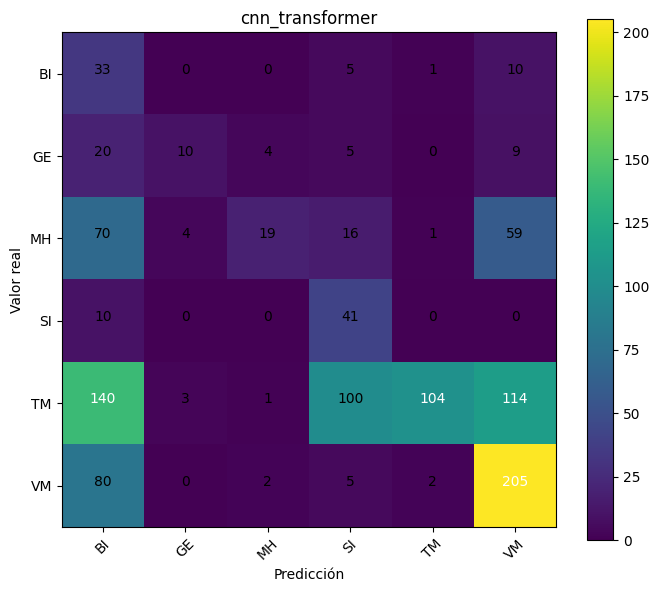


🏆 RANKING FINAL — TEST


,Modelo,Test Accuracy,Test Balanced Accuracy,Test F1 Macro,Test F1 Weighted
0,cnn_transformer,0.384,0.4534,0.3321,0.3891


In [ ]:
# =========================
# 11) EVALUACIÓN FINAL EN TEST (mejor config de cada modelo)
# =========================

# Keys posibles por modelo
PARAM_KEYS_BASE       = ["learning_rate", "dropout", "batch_size",
                          "dense_units", "fine_tune_layers"]
PARAM_KEYS_ATTENTION  = ["num_heads"]
PARAM_KEYS_TRANSFORMER = ["num_transformer_layers", "embed_dim"]

final_test_rows = []
final_objects   = {}

for model_name in MODEL_LIST:
    print("\n" + "="*90)
    print(f"🧪 Evaluación final en TEST — {model_name}")
    print("="*90)

    best = best_configs[model_name]

    # Construir dict de params de forma robusta (sin KeyError si falta alguno)
    keys = PARAM_KEYS_BASE.copy()
    if "num_heads" in best:
        keys += PARAM_KEYS_ATTENTION
    if model_name == "cnn_transformer":
        keys += PARAM_KEYS_TRANSFORMER
    params = {k: best[k] for k in keys if k in best}

    batch_size = params["batch_size"]
    _, _, test_ds, class_names = make_datasets(batch_size=batch_size)

    # Cargar mejor checkpoint
    ckpt = best["checkpoint_path"]
    if os.path.exists(ckpt):
        # custom_objects necesario para cargar modelos con capas personalizadas
        custom_objects = {
            "PositionalEmbedding":   PositionalEmbedding,
        }
        # FIX: Only add SparseCategoricalFocalLoss to custom_objects
        # if it was successfully imported and defined in the global scope.
        # This prevents NameError if the focal_loss library wasn't installed.
        if USE_FOCAL_LOSS and 'SparseCategoricalFocalLoss' in globals():
            custom_objects["SparseCategoricalFocalLoss"] = globals()['SparseCategoricalFocalLoss']
        elif USE_FOCAL_LOSS and not 'SparseCategoricalFocalLoss' in globals():
            print("WARNING: USE_FOCAL_LOSS is True, but SparseCategoricalFocalLoss class is not defined. "
                  "Skipping adding it to custom_objects. This might be due to focal_loss not being installed.")
        model = keras.models.load_model(ckpt, custom_objects=custom_objects)
        print(f"✅ Modelo cargado desde checkpoint: {ckpt}")
    else:
        print(f"⚠️ Checkpoint no encontrado — reentrenando con mejor config...")
        train_ds, val_ds, _, _ = make_datasets(batch_size=batch_size)
        model, base_model, n_ft = build_model_v2(model_name, params)
        model.fit(train_ds, validation_data=val_ds,
                  epochs=MAX_EPOCHS, class_weight=class_weights, verbose=0)

    test_metrics, y_true, y_pred, _ = evaluate_model(model, test_ds)

    print(f"\n📊 Métricas en TEST:")
    for k, v in test_metrics.items():
        print(f"  {k}: {v:.4f}")

    print(f"\n📋 Classification Report:")
    print(classification_report(y_true, y_pred,
                                target_names=class_names, zero_division=0))

    plot_conf_matrix(y_true, y_pred, class_names, title=model_name)

    row = {"Modelo": model_name,
           **{f"Test {k.replace('_',' ').title()}": round(v, 4)
              for k, v in test_metrics.items()}}
    final_test_rows.append(row)
    final_objects[model_name] = {"model": model, "y_true": y_true, "y_pred": y_pred}

    del test_ds
    gc.collect()

final_test_df = (pd.DataFrame(final_test_rows)
                 .sort_values("Test F1 Macro", ascending=False)
                 .reset_index(drop=True))

print("\n" + "="*80)
print("🏆 RANKING FINAL — TEST")
print("="*80)
display(final_test_df)

final_test_df.to_csv(
    os.path.join(OUTPUT_DIR, "ranking_final_test.csv"), index=False
)


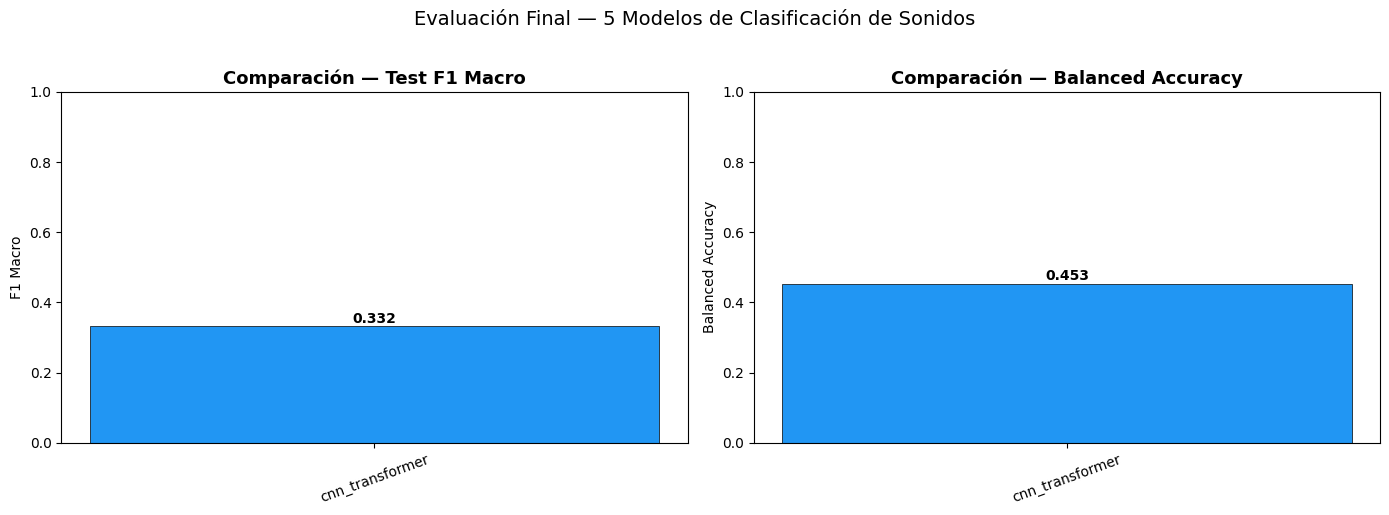


🏆 MEJOR MODELO: cnn_transformer — F1 Macro: 0.3321


In [ ]:
# =========================
# 12) COMPARACIÓN VISUAL FINAL
# =========================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colores = ["#2196F3", "#4CAF50", "#FF9800", "#E91E63", "#9C27B0"]

# F1 Macro
axes[0].bar(final_test_df["Modelo"], final_test_df["Test F1 Macro"],
            color=colores[:len(MODEL_LIST)], edgecolor="black", linewidth=0.5)
axes[0].set_title("Comparación — Test F1 Macro", fontsize=13, fontweight="bold")
axes[0].set_ylabel("F1 Macro")
axes[0].set_ylim([0, 1])
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(final_test_df["Test F1 Macro"]):
    axes[0].text(i, v + 0.01, f"{v:.3f}", ha='center', fontsize=10, fontweight="bold")

# Balanced Accuracy
axes[1].bar(final_test_df["Modelo"], final_test_df["Test Balanced Accuracy"],
            color=colores[:len(MODEL_LIST)], edgecolor="black", linewidth=0.5)
axes[1].set_title("Comparación — Balanced Accuracy", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Balanced Accuracy")
axes[1].set_ylim([0, 1])
axes[1].tick_params(axis='x', rotation=20)
for i, v in enumerate(final_test_df["Test Balanced Accuracy"]):
    axes[1].text(i, v + 0.01, f"{v:.3f}", ha='center', fontsize=10, fontweight="bold")

plt.suptitle("Evaluación Final — 5 Modelos de Clasificación de Sonidos", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "comparacion_5modelos.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"\n🏆 MEJOR MODELO: {final_test_df.iloc[0]['Modelo']} "
      f"— F1 Macro: {final_test_df.iloc[0]['Test F1 Macro']:.4f}")

## 📝 Cómo defender esto en el proyecto

### Justificación de los 5 modelos

| Modelo | Justificación académica |
|--------|-------------------------|
| `baseline_cnn` | Línea base sin transfer learning. Mide el valor del pre-entrenamiento en ImageNet para espectrogramas. |
| `mobilenetv2` + SE Block | Transfer learning clásico mejorado con recalibración de canales (Hu et al., 2018). El SE Block añade atención a nivel de canal con costo computacional mínimo. |
| `efficientnetb0` | Backbone escalado con compound scaling (Tan & Le, 2019). Referente en tareas de clasificación de imágenes. |
| `efficientnetv2s` + MHA Pooling | Estado del arte (2021). Combina backbone Fused-MBConv con atención global sobre el feature map. Captura relaciones espaciales de largo alcance en el espectrograma. |
| `cnn_transformer` (híbrido) | Arquitectura inspirada en AST (Gong et al., 2021). La CNN captura patrones tiempo-frecuencia locales; el Transformer modela contexto global. Adecuado para sonidos con estructura temporal compleja. |

### Justificación del Random Search

- Se definieron espacios de hiperparámetros específicos por arquitectura (no un espacio único).
- Se usó **F1 Macro** como criterio de selección (más robusto que accuracy ante desbalanceo).
- Se aplicaron callbacks: EarlyStopping, ReduceLROnPlateau, ModelCheckpoint.
- Se usaron **pesos de clase** para manejar desbalanceo en el dataset.
- La **SpecAugment** en entrenamiento mejora la generalización (Park et al., 2019).

### Referencias
- Howard et al. (2017). *MobileNets: Efficient Convolutional Neural Networks for Mobile Vision Applications.*
- Hu et al. (2018). *Squeeze-and-Excitation Networks.* CVPR.
- Tan & Le (2019). *EfficientNet: Rethinking Model Scaling for Convolutional Neural Networks.*
- Tan & Le (2021). *EfficientNetV2: Smaller Models and Faster Training.*
- Gong et al. (2021). *AST: Audio Spectrogram Transformer.* Interspeech.
- Park et al. (2019). *SpecAugment: A Simple Data Augmentation Method for ASR.*
- Vaswani et al. (2017). *Attention is All You Need.* NeurIPS.